<a href="https://colab.research.google.com/github/alchemistgates7/mds3-parallel-ai-training/blob/main/MDS3_Parallel_AI_Training_ASYN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [23]:
!ls -la /content/drive

total 12
drwxr-xr-x 3 root root 4096 Jul 21 13:29 .
drwxr-xr-x 1 root root 4096 Jul 21 13:29 ..
drwxr-xr-x 3 root root 4096 Jul 21 13:29 MyDrive


In [26]:
import os

data_path = "/content/gdrive/MyDrive/MDS3_pc/StockPriceDataset.csv"

print("File exists:", os.path.exists(data_path))
print("File path:", data_path)

File exists: True
File path: /content/gdrive/MyDrive/MDS3_pc/StockPriceDataset.csv


In [27]:
!pip install -q pyspark

In [28]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MDS3 Stock Price Prediction")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Default parallelism:", spark.sparkContext.defaultParallelism)

Spark version: 4.0.3
Default parallelism: 2


In [29]:
stock_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(data_path)
)

print("Spark version:", spark.version)
print("Rows:", stock_df.count())
print("Columns:", len(stock_df.columns))
print("Column names:", stock_df.columns)
print("Partitions:", stock_df.rdd.getNumPartitions())

stock_df.printSchema()
stock_df.show(10, truncate=False)


Spark version: 4.0.3
Rows: 25160
Columns: 8
Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']
Partitions: 1
root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- Ticker: string (nullable = true)

+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume   |Ticker|
+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|2014-01-02|19.845714569091797|19.89392852783203 |19.71500015258789 |19.754642486572266|17.273225784301758|234684800|AAPL  |
|2014-01-03|19.7450008392334  |19.774999618530273|19

In [30]:
from pyspark.sql import functions as F

stock_df = (
    stock_df
    .select(
        F.to_date(F.col("Date")).alias("date"),
        F.col("Ticker").cast("string").alias("ticker"),
        F.col("Open").cast("double").alias("open"),
        F.col("High").cast("double").alias("high"),
        F.col("Low").cast("double").alias("low"),
        F.col("Close").cast("double").alias("close"),
        F.col("Volume").cast("double").alias("volume")
    )
    .dropna()
    .filter(
        (F.col("open") > 0) &
        (F.col("high") > 0) &
        (F.col("low") > 0) &
        (F.col("close") > 0) &
        (F.col("volume") >= 0) &
        (F.col("high") >= F.col("low"))
    )
    .repartition(8, "ticker")
    .cache()
)

row_count = stock_df.count()

print("Rows:", row_count)
print("Columns:", stock_df.columns)
print("Partitions:", stock_df.rdd.getNumPartitions())

stock_df.printSchema()
stock_df.show(10, truncate=False)

Rows: 25160
Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']
Partitions: 8
root
 |-- date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)

+----------+------+------------------+------------------+------------------+------------------+----------+
|date      |ticker|open              |high              |low               |close             |volume    |
+----------+------+------------------+------------------+------------------+------------------+----------+
|2014-01-02|AAPL  |19.845714569091797|19.89392852783203 |19.71500015258789 |19.754642486572266|2.346848E8|
|2014-01-03|AAPL  |19.7450008392334  |19.774999618530273|19.301071166992188|19.320714950561523|3.924676E8|
|2014-01-06|AAPL  |19.194643020629883|19.5285701751709  |19.05714225769043 |19.426071166992188|4.126108E8|
|2

In [31]:
stock_df = stock_df.filter(
    (F.col("open") > 0) &
    (F.col("high") > 0) &
    (F.col("low") > 0) &
    (F.col("close") > 0) &
    (F.col("volume") >= 0) &
    (F.col("high") >= F.col("low"))
)

print("Valid rows after filtering:", stock_df.count())

summary_df = stock_df.agg(
    F.count("*").alias("total_rows"),
    F.countDistinct("ticker").alias("number_of_tickers"),
    F.min("date").alias("start_date"),
    F.max("date").alias("end_date")
)

summary_df.show(truncate=False)

TARGET_PARTITIONS = 8

stock_df = (
    stock_df
    .repartition(TARGET_PARTITIONS, "ticker")
    .sortWithinPartitions("ticker", "date")
    .cache()
)

# 触发实际计算和缓存
clean_row_count = stock_df.count()

print("Clean rows:", clean_row_count)
print("Number of partitions:", stock_df.rdd.getNumPartitions())

stock_df.select(
    "date",
    "ticker",
    "open",
    "high",
    "low",
    "close",
    "volume"
).orderBy(
    "ticker",
    "date"
).show(20, truncate=False)

Valid rows after filtering: 25160
+----------+-----------------+----------+----------+
|total_rows|number_of_tickers|start_date|end_date  |
+----------+-----------------+----------+----------+
|25160     |10               |2014-01-02|2023-12-29|
+----------+-----------------+----------+----------+

Clean rows: 25160
Number of partitions: 8
+----------+------+------------------+------------------+------------------+------------------+-----------+
|date      |ticker|open              |high              |low               |close             |volume     |
+----------+------+------------------+------------------+------------------+------------------+-----------+
|2014-01-02|AAPL  |19.845714569091797|19.89392852783203 |19.71500015258789 |19.754642486572266|2.346848E8 |
|2014-01-03|AAPL  |19.7450008392334  |19.774999618530273|19.301071166992188|19.320714950561523|3.924676E8 |
|2014-01-06|AAPL  |19.194643020629883|19.5285701751709  |19.05714225769043 |19.426071166992188|4.126108E8 |
|2014-01-0

In [32]:
# ============================================================
# Step 3: Feature Engineering and Label Creation
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window


# ------------------------------------------------------------
# 1. Define windows for each stock ordered by trading date
# ------------------------------------------------------------

stock_window = Window.partitionBy("ticker").orderBy("date")

window_5 = stock_window.rowsBetween(-4, 0)
window_10 = stock_window.rowsBetween(-9, 0)
window_20 = stock_window.rowsBetween(-19, 0)


# ------------------------------------------------------------
# 2. Generate historical features and prediction label
# ------------------------------------------------------------

feature_df = (
    stock_df

    # Historical values
    .withColumn(
        "previous_close",
        F.lag("close", 1).over(stock_window)
    )
    .withColumn(
        "close_5_days_ago",
        F.lag("close", 5).over(stock_window)
    )
    .withColumn(
        "previous_volume",
        F.lag("volume", 1).over(stock_window)
    )

    # Next-day closing price: only used to create the label
    .withColumn(
        "next_close",
        F.lead("close", 1).over(stock_window)
    )

    # One-day return
    .withColumn(
        "daily_return",
        F.col("close") / F.col("previous_close") - 1
    )

    # Five-day return
    .withColumn(
        "return_5d",
        F.col("close") / F.col("close_5_days_ago") - 1
    )

    # Five-day moving-average ratio
    .withColumn(
        "ma_ratio_5",
        F.col("close") / F.avg("close").over(window_5)
    )

    # Twenty-day moving-average ratio
    .withColumn(
        "ma_ratio_20",
        F.col("close") / F.avg("close").over(window_20)
    )

    # Ten-day return volatility
    .withColumn(
        "volatility_10d",
        F.stddev("daily_return").over(window_10)
    )

    # Daily trading-volume change
    .withColumn(
        "volume_change",
        F.when(
            F.col("previous_volume") > 0,
            F.col("volume") / F.col("previous_volume") - 1
        )
    )

    # Intraday price range
    .withColumn(
        "price_range",
        (F.col("high") - F.col("low")) / F.col("close")
    )

    # Prediction target:
    # 1 = next trading day's close is higher
    # 0 = next trading day's close is not higher
    .withColumn(
        "label",
        F.when(
            F.col("next_close") > F.col("close"),
            1.0
        ).otherwise(0.0)
    )
)


# ------------------------------------------------------------
# 3. Define model input features
# ------------------------------------------------------------

feature_columns = [
    "daily_return",
    "return_5d",
    "ma_ratio_5",
    "ma_ratio_20",
    "volatility_10d",
    "volume_change",
    "price_range"
]


# ------------------------------------------------------------
# 4. Remove rows without complete historical information
# ------------------------------------------------------------

model_df = feature_df.dropna(
    subset=feature_columns + ["next_close", "label"]
)


# ------------------------------------------------------------
# 5. Filter invalid or extreme values
# ------------------------------------------------------------

for column_name in feature_columns:
    model_df = model_df.filter(
        F.col(column_name).isNotNull()
        & (~F.isnan(F.col(column_name)))
        & (F.abs(F.col(column_name)) < 1000000)
    )


# ------------------------------------------------------------
# 6. Keep only columns required for modelling
# ------------------------------------------------------------

model_df = (
    model_df
    .select(
        "date",
        "ticker",
        *feature_columns,
        "label"
    )
    .repartition(8, "ticker")
    .cache()
)


# Trigger Spark execution and caching
model_row_count = model_df.count()


# ------------------------------------------------------------
# 7. Display dataset summary
# ------------------------------------------------------------

print("Feature engineering completed.")
print("Number of model rows:", model_row_count)
print("Number of input features:", len(feature_columns))
print("Feature columns:", feature_columns)
print("Number of partitions:", model_df.rdd.getNumPartitions())

print("\nModel schema:")
model_df.printSchema()

print("\nSample model records:")
model_df.orderBy("ticker", "date").show(
    10,
    truncate=False
)


# ------------------------------------------------------------
# 8. Check target-label distribution
# ------------------------------------------------------------

total_rows = model_df.count()

label_summary = (
    model_df
    .groupBy("label")
    .count()
    .withColumn(
        "percentage",
        F.round(F.col("count") / F.lit(total_rows) * 100, 2)
    )
    .orderBy("label")
)

print("\nLabel distribution:")
label_summary.show()


# ------------------------------------------------------------
# 9. Check date range and stock count
# ------------------------------------------------------------

print("\nDataset summary:")

model_df.agg(
    F.countDistinct("ticker").alias("number_of_stocks"),
    F.min("date").alias("start_date"),
    F.max("date").alias("end_date")
).show()

Feature engineering completed.
Number of model rows: 25100
Number of input features: 7
Feature columns: ['daily_return', 'return_5d', 'ma_ratio_5', 'ma_ratio_20', 'volatility_10d', 'volume_change', 'price_range']
Number of partitions: 8

Model schema:
root
 |-- date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- daily_return: double (nullable = true)
 |-- return_5d: double (nullable = true)
 |-- ma_ratio_5: double (nullable = true)
 |-- ma_ratio_20: double (nullable = true)
 |-- volatility_10d: double (nullable = true)
 |-- volume_change: double (nullable = true)
 |-- price_range: double (nullable = true)
 |-- label: double (nullable = false)


Sample model records:
+----------+------+---------------------+----------------------+------------------+------------------+--------------------+--------------------+--------------------+-----+
|date      |ticker|daily_return         |return_5d             |ma_ratio_5        |ma_ratio_20       |volatility_10d      |volume_cha

In [33]:
# ============================================================
# Step 4: Time Split, Spark ML Pipeline and Baseline Model
# ============================================================

import time

from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)


# ------------------------------------------------------------
# 1. Split the dataset by date
# ------------------------------------------------------------

# Training data: before 2022
# Testing data: 2022 and later
split_date = "2022-01-01"

train_df = (
    model_df
    .filter(F.col("date") < F.lit(split_date).cast("date"))
    .cache()
)

test_df = (
    model_df
    .filter(F.col("date") >= F.lit(split_date).cast("date"))
    .cache()
)

# Trigger Spark execution and caching
train_count = train_df.count()
test_count = test_df.count()

if train_count == 0 or test_count == 0:
    raise ValueError(
        "The selected split date produced an empty training or testing dataset. "
        "Please check the dataset date range."
    )

print("Time-based split completed.")
print("Split date:", split_date)
print("Training rows:", train_count)
print("Testing rows:", test_count)
print("Training partitions:", train_df.rdd.getNumPartitions())
print("Testing partitions:", test_df.rdd.getNumPartitions())


# ------------------------------------------------------------
# 2. Display the date range of each dataset
# ------------------------------------------------------------

print("\nTraining date range:")

train_df.agg(
    F.min("date").alias("start_date"),
    F.max("date").alias("end_date")
).show()

print("Testing date range:")

test_df.agg(
    F.min("date").alias("start_date"),
    F.max("date").alias("end_date")
).show()


# ------------------------------------------------------------
# 3. Encode the ticker column
# ------------------------------------------------------------

ticker_indexer = StringIndexer(
    inputCol="ticker",
    outputCol="ticker_index",
    handleInvalid="keep"
)

ticker_encoder = OneHotEncoder(
    inputCols=["ticker_index"],
    outputCols=["ticker_encoded"],
    handleInvalid="keep"
)


# ------------------------------------------------------------
# 4. Combine all features into one feature vector
# ------------------------------------------------------------

assembler_input_columns = feature_columns + ["ticker_encoded"]

assembler = VectorAssembler(
    inputCols=assembler_input_columns,
    outputCol="features",
    handleInvalid="keep"
)


# ------------------------------------------------------------
# 5. Define the fixed baseline model
# ------------------------------------------------------------

baseline_rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=20,
    maxDepth=5,
    seed=42
)


# ------------------------------------------------------------
# 6. Build the Spark ML Pipeline
# ------------------------------------------------------------

baseline_pipeline = Pipeline(
    stages=[
        ticker_indexer,
        ticker_encoder,
        assembler,
        baseline_rf
    ]
)

print("\nPipeline stages:")
print("1. StringIndexer")
print("2. OneHotEncoder")
print("3. VectorAssembler")
print("4. RandomForestClassifier")


# ------------------------------------------------------------
# 7. Train the baseline model and measure training time
# ------------------------------------------------------------

start_time = time.perf_counter()

baseline_model = baseline_pipeline.fit(train_df)

baseline_training_time = time.perf_counter() - start_time

print("\nBaseline model training completed.")
print(f"Training time: {baseline_training_time:.2f} seconds")


# ------------------------------------------------------------
# 8. Generate predictions on the testing dataset
# ------------------------------------------------------------

baseline_predictions = (
    baseline_model
    .transform(test_df)
    .cache()
)

# Trigger prediction computation
baseline_predictions.count()


# ------------------------------------------------------------
# 9. Define evaluation metrics
# ------------------------------------------------------------

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


# ------------------------------------------------------------
# 10. Evaluate the baseline model
# ------------------------------------------------------------

baseline_f1 = f1_evaluator.evaluate(baseline_predictions)
baseline_accuracy = accuracy_evaluator.evaluate(baseline_predictions)
baseline_auc = auc_evaluator.evaluate(baseline_predictions)

print("\nBaseline model results:")
print("Model: Random Forest")
print("numTrees: 20")
print("maxDepth: 5")
print("seed: 42")
print(f"Training time: {baseline_training_time:.2f} seconds")
print(f"F1-score: {baseline_f1:.4f}")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Area Under ROC: {baseline_auc:.4f}")


# ------------------------------------------------------------
# 11. Show sample predictions
# ------------------------------------------------------------

baseline_predictions.select(
    "date",
    "ticker",
    "label",
    "prediction",
    "probability"
).orderBy(
    "date",
    "ticker"
).show(
    20,
    truncate=False
)


# ------------------------------------------------------------
# 12. Create a baseline result table
# ------------------------------------------------------------

baseline_result = [
    (
        "Baseline Random Forest",
        20,
        5,
        42,
        train_df.rdd.getNumPartitions(),
        float(baseline_training_time),
        float(baseline_f1),
        float(baseline_accuracy),
        float(baseline_auc)
    )
]

baseline_result_columns = [
    "model",
    "num_trees",
    "max_depth",
    "seed",
    "partitions",
    "training_time_seconds",
    "f1_score",
    "accuracy",
    "area_under_roc"
]

baseline_result_df = spark.createDataFrame(
    baseline_result,
    baseline_result_columns
)

print("\nBaseline result table:")
baseline_result_df.show(truncate=False)

Time-based split completed.
Split date: 2022-01-01
Training rows: 20100
Testing rows: 5000
Training partitions: 8
Testing partitions: 8

Training date range:
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2014-01-09|2021-12-31|
+----------+----------+

Testing date range:
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2022-01-03|2023-12-28|
+----------+----------+


Pipeline stages:
1. StringIndexer
2. OneHotEncoder
3. VectorAssembler
4. RandomForestClassifier

Baseline model training completed.
Training time: 12.78 seconds

Baseline model results:
Model: Random Forest
numTrees: 20
maxDepth: 5
seed: 42
Training time: 12.78 seconds
F1-score: 0.4392
Accuracy: 0.5042
Area Under ROC: 0.4944
+----------+------+-----+----------+----------------------------------------+
|date      |ticker|label|prediction|probability                             |
+----------+------+-----+----------+----------------------------------------+
|2022-01-03|AAPL  

Python CPU cores: 2
Spark default parallelism: 2

Preprocessing completed.
Training rows: 20100
Testing rows: 5000
Training partitions: 8

Number of configurations: 4
E1: numTrees=20, maxDepth=5
E2: numTrees=20, maxDepth=10
E3: numTrees=50, maxDepth=5
E4: numTrees=50, maxDepth=10

Running a small warm-up model...
Warm-up completed.

Benchmark round 1
Running parallelism=1...
Completed: parallelism=1, time=50.04 seconds
Running parallelism=2...
Completed: parallelism=2, time=37.71 seconds
Running parallelism=4...
Completed: parallelism=4, time=35.51 seconds

Benchmark round 2
Running parallelism=4...
Completed: parallelism=4, time=33.11 seconds
Running parallelism=2...
Completed: parallelism=2, time=31.71 seconds
Running parallelism=1...
Completed: parallelism=1, time=31.34 seconds

Raw benchmark results:


,round,parallelism,models_evaluated,time_seconds
0,1,1,4,50.04
1,1,2,4,37.71
2,1,4,4,35.51
3,2,4,4,33.11
4,2,2,4,31.71
5,2,1,4,31.34



Final timing comparison:


,parallelism,models_evaluated,number_of_runs,mean_time_seconds,median_time_seconds,minimum_time_seconds,maximum_time_seconds,speedup
0,1,4,2,40.69,40.69,31.34,50.04,1.00
1,2,4,2,34.71,34.71,31.71,37.71,1.17
2,4,4,2,34.31,34.31,33.11,35.51,1.19



Configuration comparison:


,configuration,num_trees,max_depth,validation_f1
0,E2,20,10,0.4972
1,E4,50,10,0.4954
2,E3,50,5,0.4522
3,E1,20,5,0.4417



Best configuration:
Configuration: E2
numTrees: 20
maxDepth: 10
Validation F1: 0.4972

Best model external test results:
Test F1: 0.4700
Test Accuracy: 0.4980
Test AUC: 0.4864


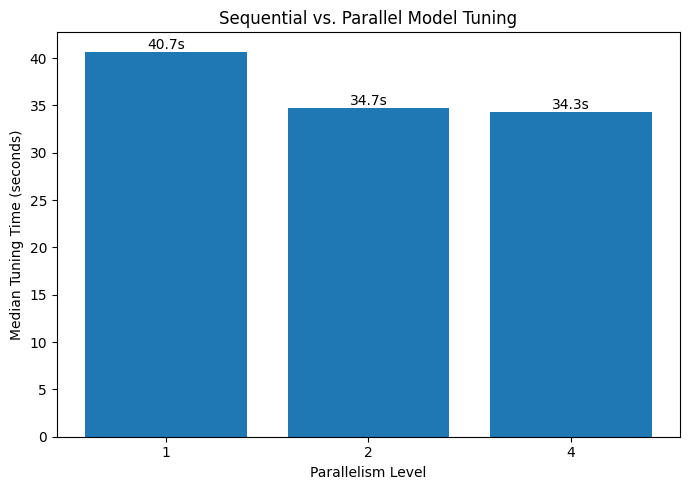

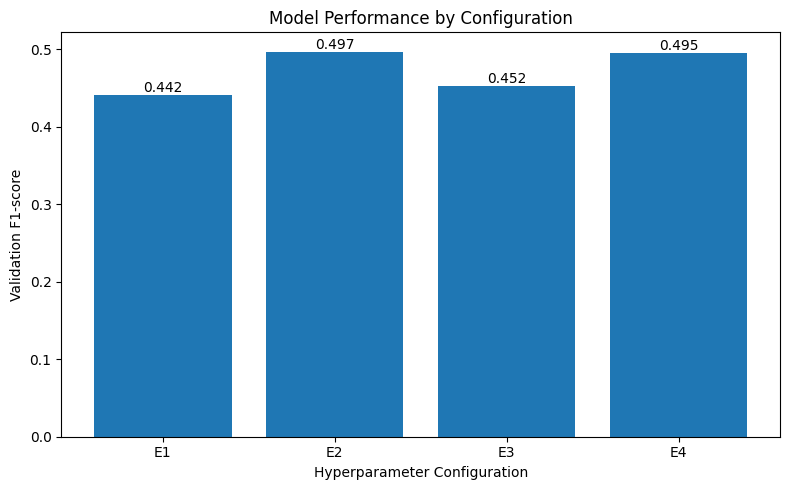


STEP 5 FINAL RESULTS


,parallelism,models_evaluated,median_time_seconds,speedup
0,1,4,40.69,1.00
1,2,4,34.71,1.17
2,4,4,34.31,1.19


Best configuration: E2
Best numTrees: 20
Best maxDepth: 10
Best validation F1: 0.4972
Best test F1: 0.4700
Best test Accuracy: 0.4980
Best test AUC: 0.4864


In [34]:
# ============================================================
# Step 5: Reliable Sequential vs. Parallel Model Tuning
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit


# ------------------------------------------------------------
# 1. Check available computing resources
# ------------------------------------------------------------

print("Python CPU cores:", os.cpu_count())
print(
    "Spark default parallelism:",
    spark.sparkContext.defaultParallelism
)


# ------------------------------------------------------------
# 2. Preprocess the data only once
# ------------------------------------------------------------

preprocessing_pipeline = Pipeline(stages=[
    ticker_indexer,
    ticker_encoder,
    assembler
])

preprocessing_model = preprocessing_pipeline.fit(train_df)

train_features = (
    preprocessing_model
    .transform(train_df)
    .select("features", "label")
    .cache()
)

test_features = (
    preprocessing_model
    .transform(test_df)
    .select("features", "label")
    .cache()
)

# Materialize the cache before timing experiments
train_feature_count = train_features.count()
test_feature_count = test_features.count()

print("\nPreprocessing completed.")
print("Training rows:", train_feature_count)
print("Testing rows:", test_feature_count)
print(
    "Training partitions:",
    train_features.rdd.getNumPartitions()
)


# ------------------------------------------------------------
# 3. Define Random Forest and parameter grid
# ------------------------------------------------------------

tuning_rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    seed=42
)

param_grid = (
    ParamGridBuilder()
    .addGrid(tuning_rf.numTrees, [20, 50])
    .addGrid(tuning_rf.maxDepth, [5, 10])
    .build()
)

print("\nNumber of configurations:", len(param_grid))

for index, param_map in enumerate(param_grid):
    print(
        f"E{index + 1}: "
        f"numTrees={param_map[tuning_rf.numTrees]}, "
        f"maxDepth={param_map[tuning_rf.maxDepth]}"
    )


# ------------------------------------------------------------
# 4. Run a small untimed warm-up
# ------------------------------------------------------------

warmup_df = (
    train_features
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .cache()
)

warmup_df.count()

warmup_rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=5,
    maxDepth=2,
    seed=42
)

print("\nRunning a small warm-up model...")
warmup_rf.fit(warmup_df)

warmup_df.unpersist()

print("Warm-up completed.")


# ------------------------------------------------------------
# 5. Define one tuning experiment
# ------------------------------------------------------------

def run_tuning(parallelism_level):
    """
    Run one TrainValidationSplit experiment.

    Returns
    -------
    model:
        Fitted TrainValidationSplitModel.
    elapsed_time:
        Total runtime in seconds.
    """

    tuner = TrainValidationSplit(
        estimator=tuning_rf,
        estimatorParamMaps=param_grid,
        evaluator=f1_evaluator,
        trainRatio=0.8,
        parallelism=parallelism_level,
        seed=42
    )

    gc.collect()

    start_time = time.perf_counter()

    fitted_model = tuner.fit(train_features)

    elapsed_time = time.perf_counter() - start_time

    return fitted_model, elapsed_time


# ------------------------------------------------------------
# 6. Benchmark parallelism 1, 2 and 4
# ------------------------------------------------------------

# Reverse the order in round 2 to reduce ordering bias
run_orders = [
    [1, 2, 4],
    [4, 2, 1]
]

benchmark_records = []
models_by_parallelism = {}

for round_number, parallelism_order in enumerate(
    run_orders,
    start=1
):

    print(f"\nBenchmark round {round_number}")

    for parallelism_level in parallelism_order:

        print(
            f"Running parallelism={parallelism_level}..."
        )

        fitted_model, elapsed_time = run_tuning(
            parallelism_level
        )

        models_by_parallelism[
            parallelism_level
        ] = fitted_model

        benchmark_records.append({
            "round": round_number,
            "parallelism": parallelism_level,
            "models_evaluated": len(param_grid),
            "time_seconds": elapsed_time
        })

        print(
            f"Completed: parallelism="
            f"{parallelism_level}, "
            f"time={elapsed_time:.2f} seconds"
        )

        # Small pause between experiments
        time.sleep(2)


# ------------------------------------------------------------
# 7. Show the raw benchmark results
# ------------------------------------------------------------

benchmark_raw_df = pd.DataFrame(
    benchmark_records
)

benchmark_raw_df["time_seconds"] = (
    benchmark_raw_df["time_seconds"].round(2)
)

print("\nRaw benchmark results:")
display(benchmark_raw_df)


# ------------------------------------------------------------
# 8. Calculate median runtime and speedup
# ------------------------------------------------------------

timing_results = (
    benchmark_raw_df
    .groupby("parallelism", as_index=False)
    .agg(
        models_evaluated=(
            "models_evaluated",
            "first"
        ),
        number_of_runs=(
            "time_seconds",
            "count"
        ),
        mean_time_seconds=(
            "time_seconds",
            "mean"
        ),
        median_time_seconds=(
            "time_seconds",
            "median"
        ),
        minimum_time_seconds=(
            "time_seconds",
            "min"
        ),
        maximum_time_seconds=(
            "time_seconds",
            "max"
        )
    )
)

baseline_median_time = timing_results.loc[
    timing_results["parallelism"] == 1,
    "median_time_seconds"
].iloc[0]

timing_results["speedup"] = (
    baseline_median_time
    / timing_results["median_time_seconds"]
)

timing_results[
    [
        "mean_time_seconds",
        "median_time_seconds",
        "minimum_time_seconds",
        "maximum_time_seconds",
        "speedup"
    ]
] = timing_results[
    [
        "mean_time_seconds",
        "median_time_seconds",
        "minimum_time_seconds",
        "maximum_time_seconds",
        "speedup"
    ]
].round(2)

print("\nFinal timing comparison:")
display(timing_results)


# ------------------------------------------------------------
# 9. Compare the four hyperparameter configurations
# ------------------------------------------------------------

# Use the last parallelism=2 model as the reference.
# Model metrics should remain consistent because the seed is fixed.
reference_tuning_model = models_by_parallelism[2]

validation_metrics = [
    float(metric)
    for metric in reference_tuning_model.validationMetrics
]

configuration_results = []

for index, param_map in enumerate(param_grid):

    configuration_results.append({
        "configuration": f"E{index + 1}",
        "num_trees": int(
            param_map[tuning_rf.numTrees]
        ),
        "max_depth": int(
            param_map[tuning_rf.maxDepth]
        ),
        "validation_f1": round(
            validation_metrics[index],
            4
        )
    })

configuration_results_df = (
    pd.DataFrame(configuration_results)
    .sort_values(
        by="validation_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nConfiguration comparison:")
display(configuration_results_df)


# ------------------------------------------------------------
# 10. Identify the best configuration
# ------------------------------------------------------------

best_index = int(
    np.argmax(validation_metrics)
)

best_param_map = param_grid[best_index]

best_configuration = f"E{best_index + 1}"

best_num_trees = int(
    best_param_map[tuning_rf.numTrees]
)

best_max_depth = int(
    best_param_map[tuning_rf.maxDepth]
)

best_validation_f1 = float(
    validation_metrics[best_index]
)

print("\nBest configuration:")
print("Configuration:", best_configuration)
print("numTrees:", best_num_trees)
print("maxDepth:", best_max_depth)
print(
    f"Validation F1: "
    f"{best_validation_f1:.4f}"
)


# ------------------------------------------------------------
# 11. Evaluate the best model on the external test set
# ------------------------------------------------------------

best_model = reference_tuning_model.bestModel

best_predictions = (
    best_model
    .transform(test_features)
    .cache()
)

best_predictions.count()

best_test_f1 = float(
    f1_evaluator.evaluate(best_predictions)
)

best_test_accuracy = float(
    accuracy_evaluator.evaluate(best_predictions)
)

best_test_auc = float(
    auc_evaluator.evaluate(best_predictions)
)

print("\nBest model external test results:")
print(f"Test F1: {best_test_f1:.4f}")
print(f"Test Accuracy: {best_test_accuracy:.4f}")
print(f"Test AUC: {best_test_auc:.4f}")


# ------------------------------------------------------------
# 12. Plot median tuning time
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

bars = plt.bar(
    timing_results["parallelism"].astype(str),
    timing_results["median_time_seconds"]
)

plt.xlabel("Parallelism Level")
plt.ylabel("Median Tuning Time (seconds)")
plt.title(
    "Sequential vs. Parallel Model Tuning"
)

for bar, value in zip(
    bars,
    timing_results["median_time_seconds"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Plot validation F1 by configuration
# ------------------------------------------------------------

plot_configuration_df = (
    configuration_results_df
    .sort_values("configuration")
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_configuration_df["configuration"],
    plot_configuration_df["validation_f1"]
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Validation F1-score")
plt.title(
    "Model Performance by Configuration"
)

for bar, value in zip(
    bars,
    plot_configuration_df["validation_f1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 5 FINAL RESULTS")
print("=" * 60)

display(
    timing_results[
        [
            "parallelism",
            "models_evaluated",
            "median_time_seconds",
            "speedup"
        ]
    ]
)

print("Best configuration:", best_configuration)
print("Best numTrees:", best_num_trees)
print("Best maxDepth:", best_max_depth)
print(
    f"Best validation F1: "
    f"{best_validation_f1:.4f}"
)
print(f"Best test F1: {best_test_f1:.4f}")
print(f"Best test Accuracy: {best_test_accuracy:.4f}")
print(f"Best test AUC: {best_test_auc:.4f}")

print("=" * 60)

In [38]:
import os

results_dir = "/content/gdrive/MyDrive/MDS3_pc/results"
os.makedirs(results_dir, exist_ok=True)

benchmark_raw_df.to_csv(
    f"{results_dir}/benchmark_raw_results.csv",
    index=False
)

timing_results.to_csv(
    f"{results_dir}/parallelism_timing_results.csv",
    index=False
)

configuration_results_df.to_csv(
    f"{results_dir}/configuration_results.csv",
    index=False
)

print("Results saved to:", results_dir)


Results saved to: /content/gdrive/MyDrive/MDS3_pc/results


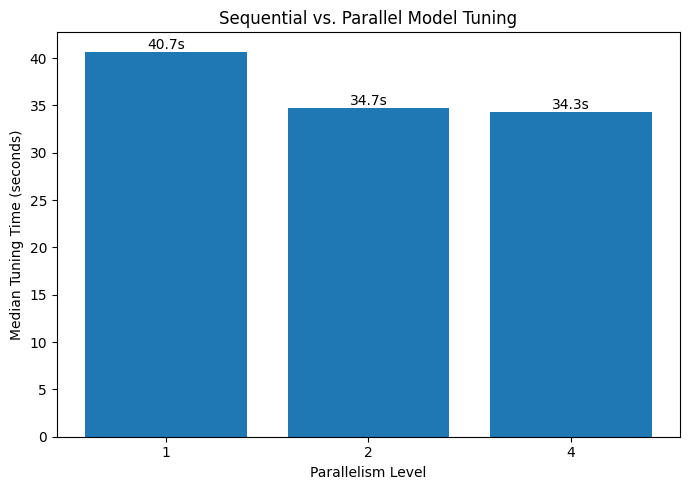

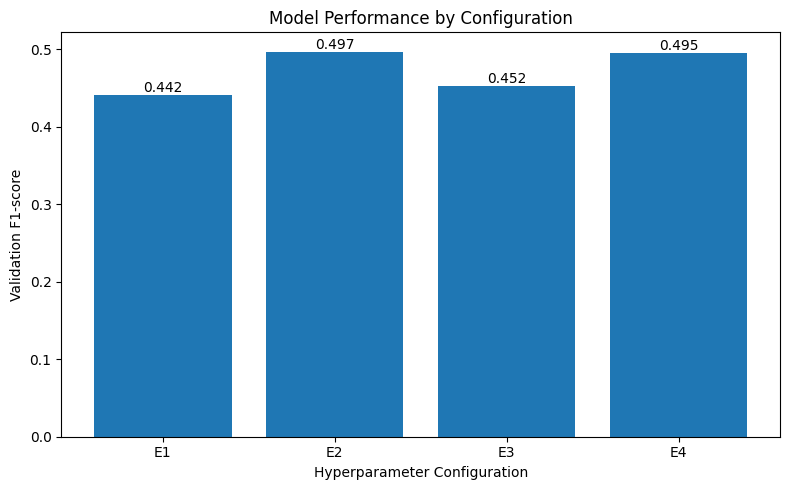

In [36]:
import matplotlib.pyplot as plt

# Parallelism execution-time chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    timing_results["parallelism"].astype(str),
    timing_results["median_time_seconds"]
)

plt.xlabel("Parallelism Level")
plt.ylabel("Median Tuning Time (seconds)")
plt.title("Sequential vs. Parallel Model Tuning")

for bar, value in zip(
    bars,
    timing_results["median_time_seconds"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}s",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    f"{results_dir}/parallelism_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Hyperparameter configuration chart
plot_df = configuration_results_df.sort_values("configuration")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_df["configuration"],
    plot_df["validation_f1"]
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Validation F1-score")
plt.title("Model Performance by Configuration")

for bar, value in zip(
    bars,
    plot_df["validation_f1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    f"{results_dir}/configuration_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@ba583ff40e48.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/alchemistgates7/mds3-parallel-a